In [ ]:
import wfdb;
import numpy as np;
import matplotlib.pyplot as plt;
#Objeto wfdb, aplica función dl_database para descargar la base de datos 'mitdb'
#En la ubicación '../data/mitdb', y descarga los registros '100', '106' y '200'.
wfdb.dl_database('mitdb', dl_dir='../data/mitdb', records=['100', '106', '200'])
#función rdrecord busca el registro de la ruta dada, y lo almacena en record, que es un objeto de la clase Record. 
# Este objeto contiene información sobre la señal, como el número de canales, la frecuencia de muestreo, 
# el número de muestras, etc.
record = wfdb.rdrecord('../data/mitdb/100')


Generating record list for: 100
Generating record list for: 106
Generating record list for: 200
Generating list of all files for: 100
Generating list of all files for: 106
Generating list of all files for: 200
Finished downloading files


In [ ]:
def bandpass_filter(signal, lowcut, highcut, fs, order):
    from scipy.signal import butter, filtfilt
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, signal)
    return y

(0.0, 10.0)

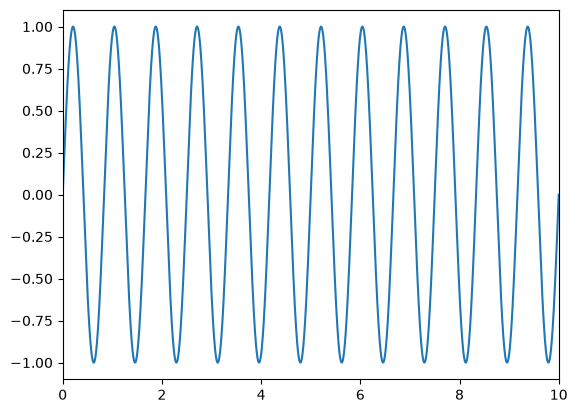

In [37]:
#Creamos una señal cualquiera, sabemos que la frecuencia de muestreo es de 360 Hz
#La frecuencia de la señal es de 30 Hz, nos servirá para probar el filtro
fm = 1.2 #Frecuencia del latido
fs = 360 #Frecuencia de muestreo
duración = 10
x = np.linspace(0, duración, int(fs * duración))
latido = np.sin(2 * np.pi * fm * x)

plt.plot(x, latido)
plt.xlim(0, 10)

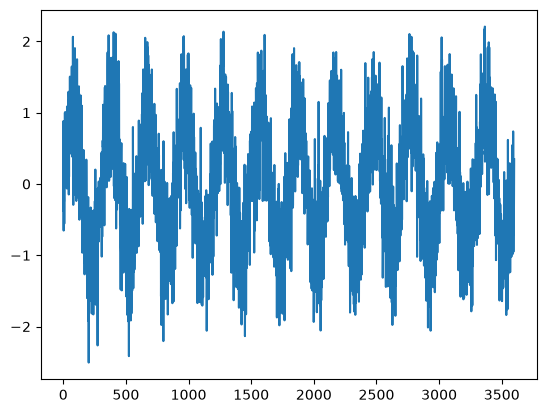

In [40]:
#Pero esta señal aún no tiene ruido, por lo que primero le añadiremos ruido de forma aleatoria para 
#Simular una señal real, y luego aplicaremos el filtro para ver si es capaz de eliminar el ruido.
ruido = np.random.normal(0, 0.5, latido.shape)
latido_ruidoso = latido + ruido
plt.plot(latido_ruidoso)

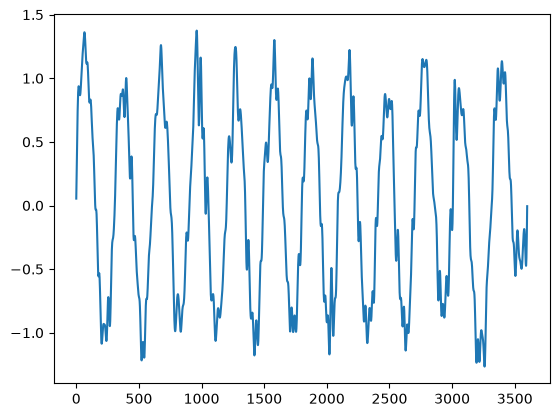

In [54]:
#Ya tenemos la señal con ruido, ahora aplicamos el filtro para ver si es capaz de eliminar el ruido.
latido_filtrado = bandpass_filter(latido_ruidoso, 0.5, 15, fs, order=5) 
#Usamos de Frecuencia de corte alta de 15 Hz ya que es una señal sintética
#Para señales reales, se puede usar una frecuencia de corte alta de 40 Hz, ya que la mayoría de las señales de ECG tienen frecuencias menores a 40 Hz.
plt.plot(latido_filtrado)

(0.0, 3600.0)

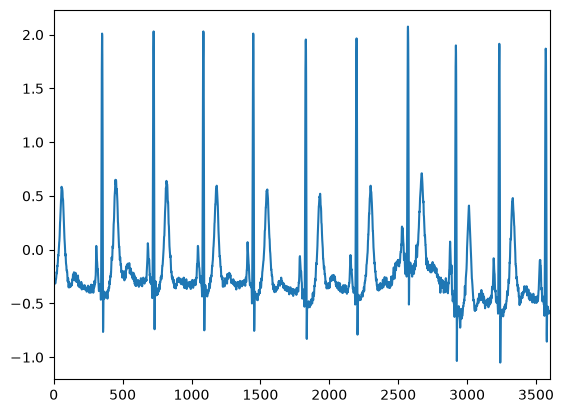

In [61]:
#Podemos ver que nuestra señal filtrada es muy similar a la señal original, con menos ruido.
#También podemos decir que nuestro filtro es capaz de eliminar el ruido de la señal.
#Pero, ahora tenemos que aplicar el filtro a una señal real, para ver si es capaz de eliminar el ruido de la señal.

record = wfdb.rdrecord('../data/mitdb/106')
final = int(10 * record.fs)  # 10 segundos de datos
time = np.arange(0, final) / record.fs
seg = record.p_signal[:final, 0]  # Tomamos solo el primer canal
plt.plot(seg)
plt.xlim(0, final)

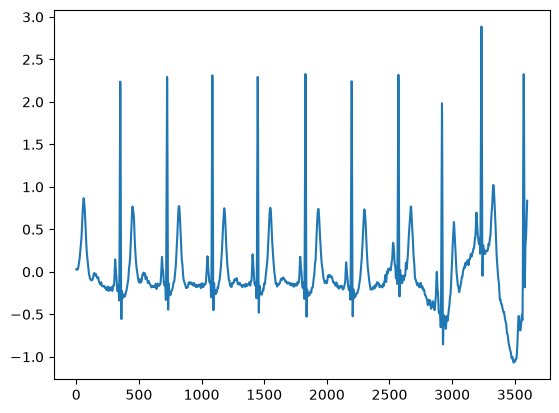

In [62]:
#Aquí ya vemos que la señal tiene un poco de ruido, pero no es mucho, por lo que aplicaremos el filtro para ver si es capaz de eliminar el ruido.
seg_filtrada = bandpass_filter(seg, 0.5, 40, record.fs, order=5)
plt.plot(seg_filtrada)

In [65]:
#Nótese que la señal filtrada es muy similar a la señal original, con menos ruido. Esto nos indica que nuestro filtro es capaz de eliminar el ruido de la señal.
#Pero, podemos medir esto?, si, utilizaremos np.corrcoef para medir la correlación entre la señal original y la señal filtrada, 
#Si el valor es cercano a 1, significa que las señales son muy similares.
correlacion = np.corrcoef(seg, seg_filtrada)[0, 1]
print(f'Correlación entre la señal original y la señal filtrada:' , correlacion)
#Haremos lo mismo con la señal sintética, para ver si el filtro es capaz de eliminar el ruido de la señal sintética.
correlacion_sintetica = np.corrcoef(latido, latido_filtrado)[0, 1]
print(f'Correlación entre la señal sintética y la señal filtrada:' , correlacion_sintetica)

Correlación entre la señal original y la señal filtrada: 0.8708512162958689
Correlación entre la señal sintética y la señal filtrada: 0.9638524197691224


In [66]:
#Pero, vale la pena preguntarse si esa diferencia a 1 es por ruido residual, o si realmente el filtro está eliminando información de la señal. 
#Para esto, podemos filrar nuevamenta la señal filtrada, y ver si la correlación entre la señal filtrada y la señal filtrada nuevamente es cercana a 1.
seg_filtrada_nuevamente = bandpass_filter(seg_filtrada, 0.5, 40, record.fs, order=5)
correlacion_filtrada = np.corrcoef(seg_filtrada, seg_filtrada_nuevamente)[0, 1]
print(f'Correlación entre la señal filtrada y la señal filtrada nuevamente:' , correlacion_filtrada)

Correlación entre la señal filtrada y la señal filtrada nuevamente: 0.989333826361198
